# Liver Disease Prediction — Exploratory Data Analysis

**Dataset**: [Predict Liver Disease — 1700 Records](https://www.kaggle.com/datasets/rabieelkharoua/predict-liver-disease-1700-records-dataset)  
**Features**: 10 clinical + demographic features, binary target (`Diagnosis`)  
**Goal**: Understand distributions, relationships, and predictive signal before modelling.

All logic lives in `src/` — this notebook is pure narrative + visualization.

In [1]:
import sys
from pathlib import Path

# Allow imports from project root
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

from src.config import load_settings
from src.data.loader import load_raw_data
from src.data.validation import run_all_validations
from src.features.schema import CATEGORICAL_FEATURES, NUMERIC_FEATURES, TARGET
from src.features.woe import iv_summary_table
from src.features.woe_viz import plot_iv_comparison, plot_woe_bars, validate_woe_monotonicity
from src.visualization.eda_plots import (
    crosstabulate,
    plot_boxplot,
    plot_correlation_matrix,
    plot_percentage_stacked_chart,
)

settings = load_settings()
print('Setup complete.')

Setup complete.


## 1. Load & Validate Data

In [2]:
df = load_raw_data(settings)
print(f'Shape: {df.shape}')
print(f'\nTarget distribution:')
print(df[TARGET].value_counts())
print(f'\nPositive rate: {(df[TARGET] == "Positive").mean():.2%}')

Shape: (1700, 11)

Target distribution:
Diagnosis
Positive    936
Negative    764
Name: count, dtype: int64

Positive rate: 55.06%


In [3]:
warnings = run_all_validations(df)
if warnings:
    print('Validation warnings:')
    for w in warnings:
        print(f'  - {w}')
else:
    print('All validations passed. No issues found.')

All validations passed. No issues found.


In [4]:
df.head()

,Age,Gender,BMI,AlcoholConsumption,Smoking,GeneticRisk,PhysicalActivity,Diabetes,Hypertension,LiverFunctionTest,Diagnosis
0,58,Male,35.857584,17.272828,No,Medium,0.658940,No,No,42.734240,Positive
1,71,Female,30.732470,2.201266,No,Medium,1.670557,Yes,No,67.309822,Positive
2,48,Male,19.971407,18.500944,No,Low,9.928308,No,No,63.738956,Negative
3,34,Female,16.615417,12.632870,No,Low,5.630129,No,No,64.555873,Positive
4,62,Female,16.065830,1.087815,No,Medium,3.566218,Yes,No,77.868689,Positive


## 2. Descriptive Statistics

In [5]:
df[NUMERIC_FEATURES].describe().round(2)

,Age,BMI,AlcoholConsumption,PhysicalActivity,LiverFunctionTest
count,1700.00,1700.00,1700.00,1700.00,1700.00
mean,50.39,27.70,9.83,5.00,59.86
std,17.64,7.21,5.76,2.85,23.00
min,20.00,15.00,0.00,0.00,20.02
25%,35.00,21.46,4.84,2.62,40.02
50%,51.00,27.93,9.83,5.02,59.51
75%,66.00,33.96,14.87,7.40,79.43
max,80.00,39.99,19.95,9.99,99.99


In [6]:
# Group by diagnosis
df.groupby(TARGET)[NUMERIC_FEATURES].mean().round(2)

,Age,BMI,AlcoholConsumption,PhysicalActivity,LiverFunctionTest
Diagnosis,,,,,
Negative,47.35,26.36,7.61,5.37,50.86
Positive,52.88,28.79,11.65,4.70,67.22


## 3. Numeric Features vs Diagnosis

100% stacked bar charts show the proportion of Positive/Negative diagnoses within quantile bins.  
Percentage labels annotated on each segment.

,bin,Negative,Positive,total,negative_pct,positive_pct
0,"(19.999, 25.0]",98,76,174,56.3,43.7
1,"(25.0, 32.0]",91,87,178,51.1,48.9
2,"(32.0, 39.0]",89,79,168,53.0,47.0
3,"(39.0, 45.0]",114,72,186,61.3,38.7
4,"(45.0, 51.0]",78,91,169,46.2,53.8
5,"(51.0, 56.0]",56,106,162,34.6,65.4
6,"(56.0, 63.0]",48,120,168,28.6,71.4
7,"(63.0, 69.0]",66,102,168,39.3,60.7
8,"(69.0, 74.0]",66,94,160,41.2,58.8
9,"(74.0, 80.0]",58,109,167,34.7,65.3


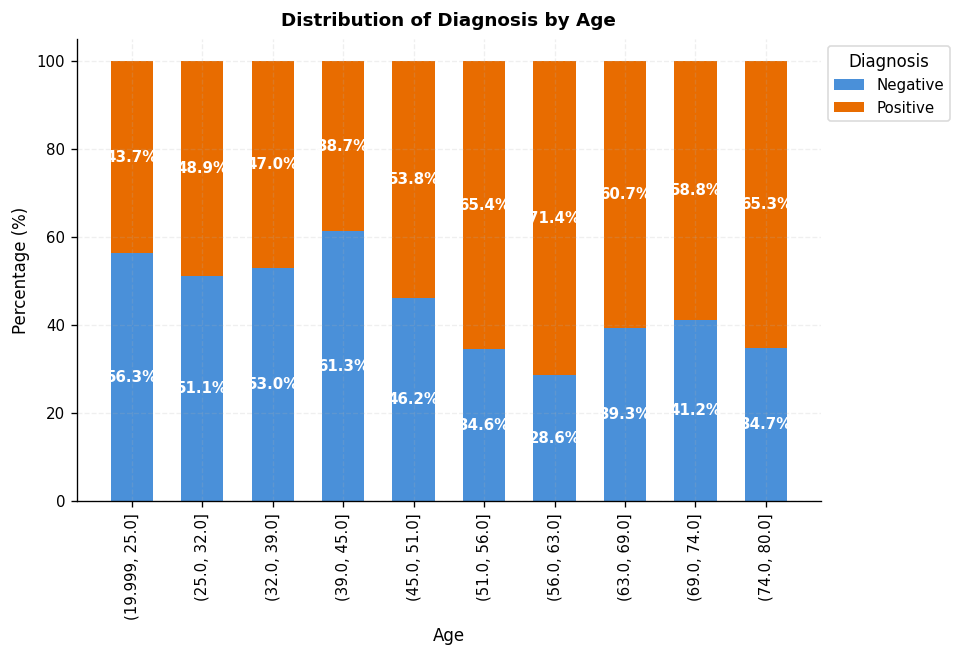

,bin,Negative,Positive,total,negative_pct,positive_pct
0,"(15.004000000000001, 17.47]",95,75,170,55.9,44.1
1,"(17.47, 20.196]",107,63,170,62.9,37.1
2,"(20.196, 22.92]",91,79,170,53.5,46.5
3,"(22.92, 25.391]",86,84,170,50.6,49.4
4,"(25.391, 27.925]",71,99,170,41.8,58.2
5,"(27.925, 30.313]",64,106,170,37.6,62.4
6,"(30.313, 32.996]",58,112,170,34.1,65.9
7,"(32.996, 35.168]",65,105,170,38.2,61.8
8,"(35.168, 37.362]",64,106,170,37.6,62.4
9,"(37.362, 39.993]",63,107,170,37.1,62.9


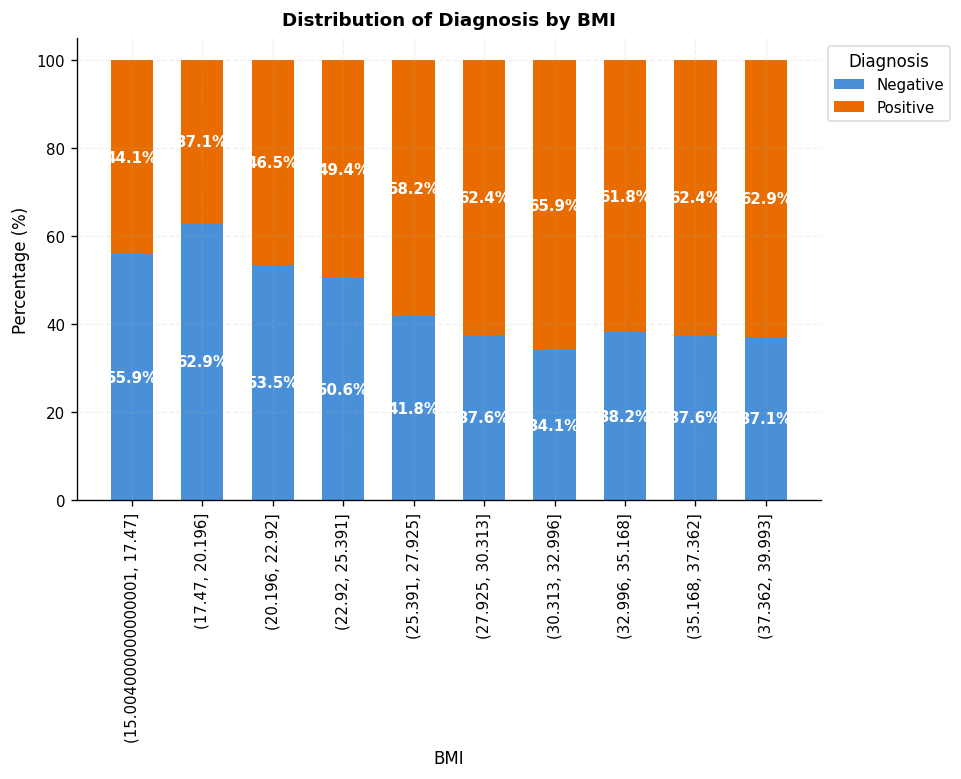

,bin,Negative,Positive,total,negative_pct,positive_pct
0,"(0.00273, 1.97]",116,54,170,68.2,31.8
1,"(1.97, 3.89]",104,66,170,61.2,38.8
2,"(3.89, 5.759]",106,64,170,62.4,37.6
3,"(5.759, 7.689]",115,55,170,67.6,32.4
4,"(7.689, 9.828]",105,65,170,61.8,38.2
5,"(9.828, 11.901]",57,113,170,33.5,66.5
6,"(11.901, 13.895]",40,130,170,23.5,76.5
7,"(13.895, 15.826]",33,137,170,19.4,80.6
8,"(15.826, 17.792]",42,128,170,24.7,75.3
9,"(17.792, 19.952]",46,124,170,27.1,72.9


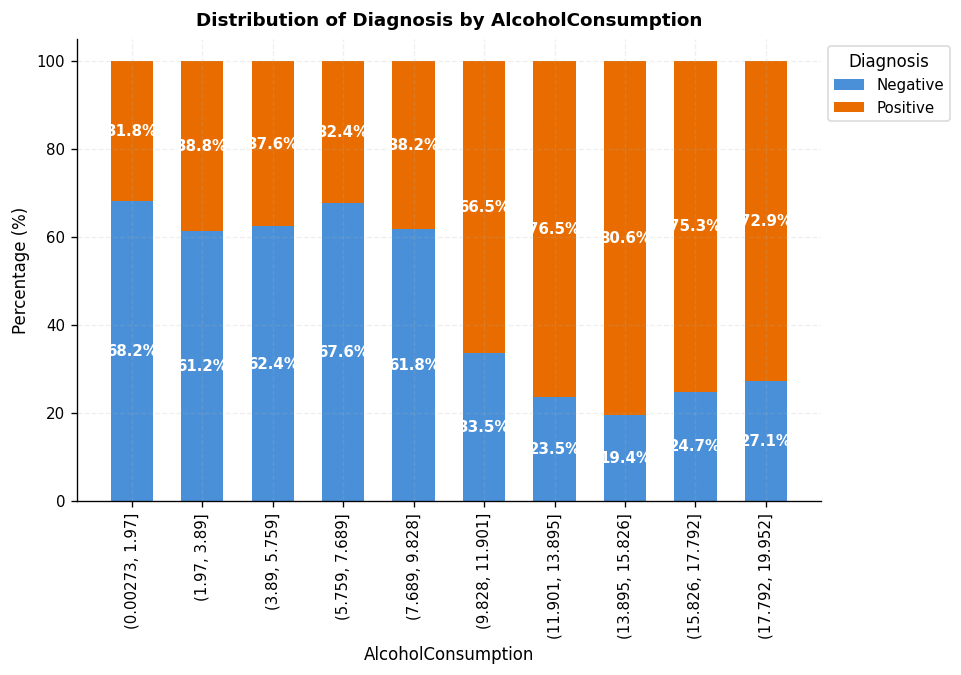

,bin,Negative,Positive,total,negative_pct,positive_pct
0,"(0.0008500000000000001, 0.992]",55,115,170,32.4,67.6
1,"(0.992, 2.103]",42,128,170,24.7,75.3
2,"(2.103, 3.103]",87,83,170,51.2,48.8
3,"(3.103, 4.157]",78,92,170,45.9,54.1
4,"(4.157, 5.023]",83,87,170,48.8,51.2
5,"(5.023, 5.991]",86,84,170,50.6,49.4
6,"(5.991, 6.885]",78,92,170,45.9,54.1
7,"(6.885, 7.918]",90,80,170,52.9,47.1
8,"(7.918, 8.97]",80,90,170,47.1,52.9
9,"(8.97, 9.995]",85,85,170,50.0,50.0


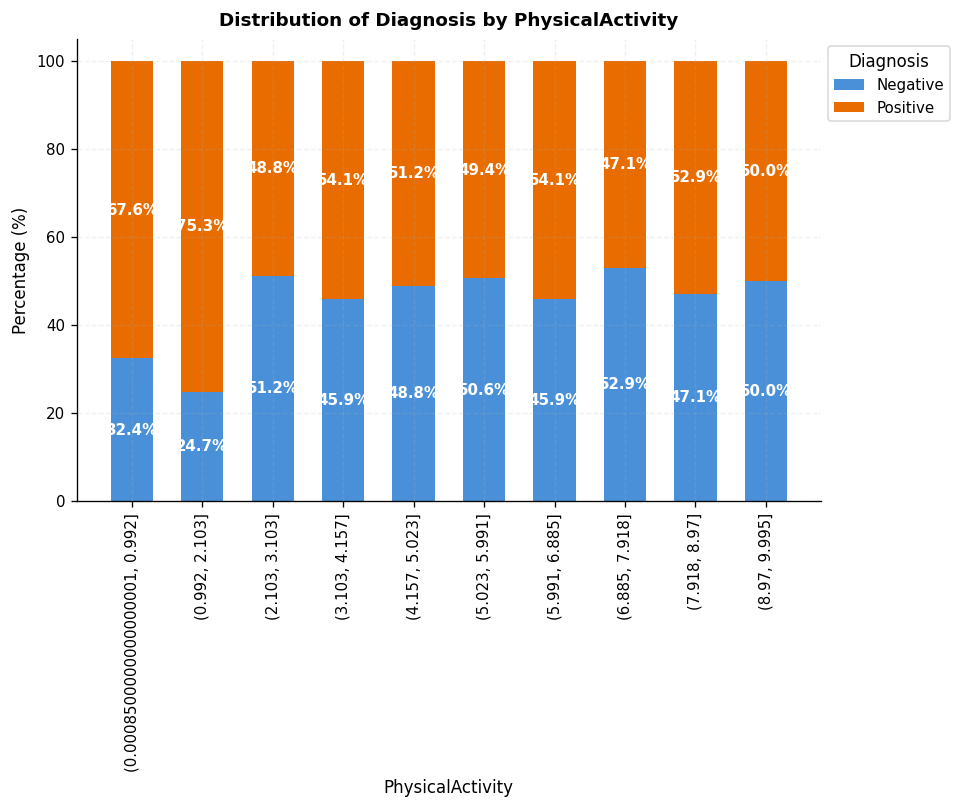

,bin,Negative,Positive,total,negative_pct,positive_pct
0,"(20.017999999999997, 28.73]",127,43,170,74.7,25.3
1,"(28.73, 36.283]",116,54,170,68.2,31.8
2,"(36.283, 44.198]",120,50,170,70.6,29.4
3,"(44.198, 51.475]",106,64,170,62.4,37.6
4,"(51.475, 59.513]",49,121,170,28.8,71.2
5,"(59.513, 66.754]",54,116,170,31.8,68.2
6,"(66.754, 75.169]",51,119,170,30.0,70.0
7,"(75.169, 84.401]",47,123,170,27.6,72.4
8,"(84.401, 92.276]",48,122,170,28.2,71.8
9,"(92.276, 99.991]",46,124,170,27.1,72.9


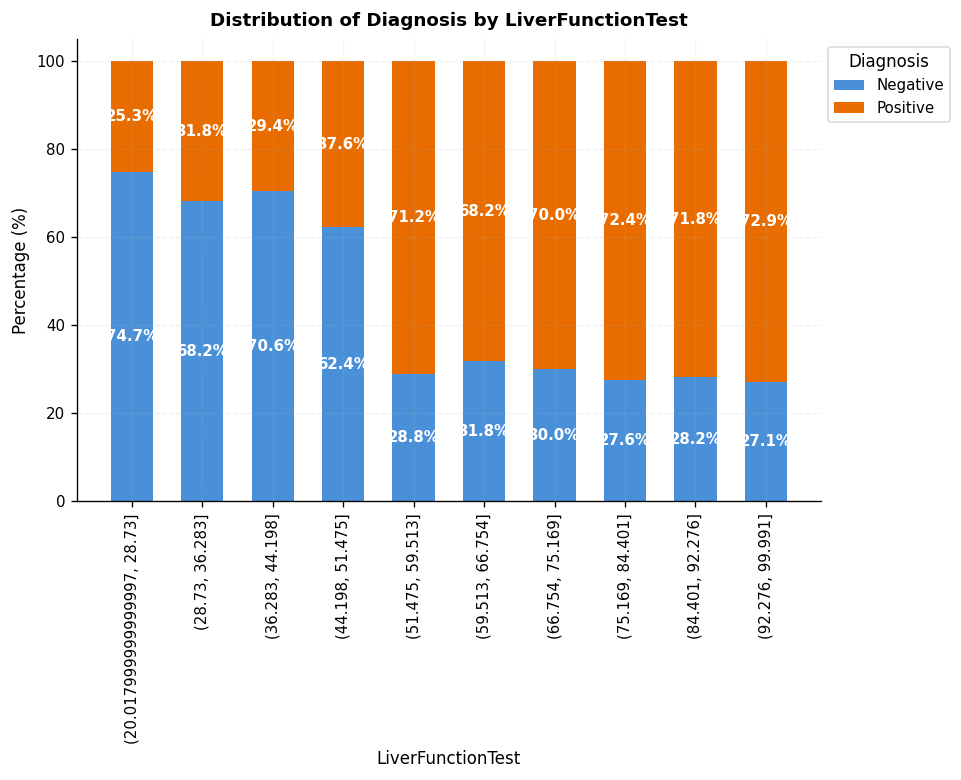

In [7]:
for feat in NUMERIC_FEATURES:
    ct = crosstabulate(df, feat, TARGET)
    display(ct[['bin', 'Negative', 'Positive', 'total', 'negative_pct', 'positive_pct']])
    plot_percentage_stacked_chart(
        ct,
        title=f'Distribution of Diagnosis by {feat}',
        xlabel=feat,
        angle=90,
    )
    plt.show()
    print()

## 4. Categorical Features vs Diagnosis

100% stacked bar charts showing the proportion of Positive/Negative diagnoses within each category.

,bin,Negative,Positive,total,negative_pct,positive_pct
0,Female,305,552,857,35.6,64.4
1,Male,459,384,843,54.4,45.6


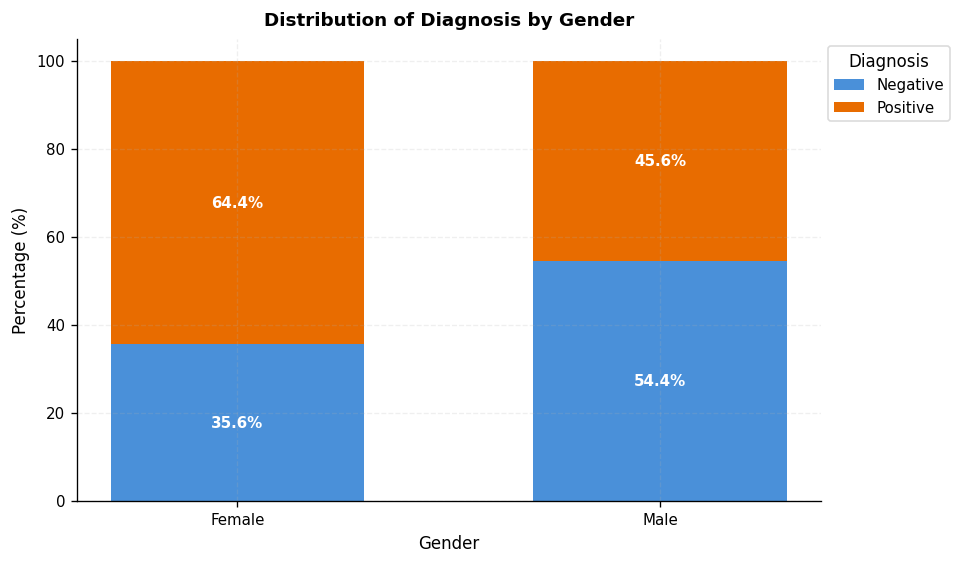

,bin,Negative,Positive,total,negative_pct,positive_pct
0,No,618,586,1204,51.3,48.7
1,Yes,146,350,496,29.4,70.6


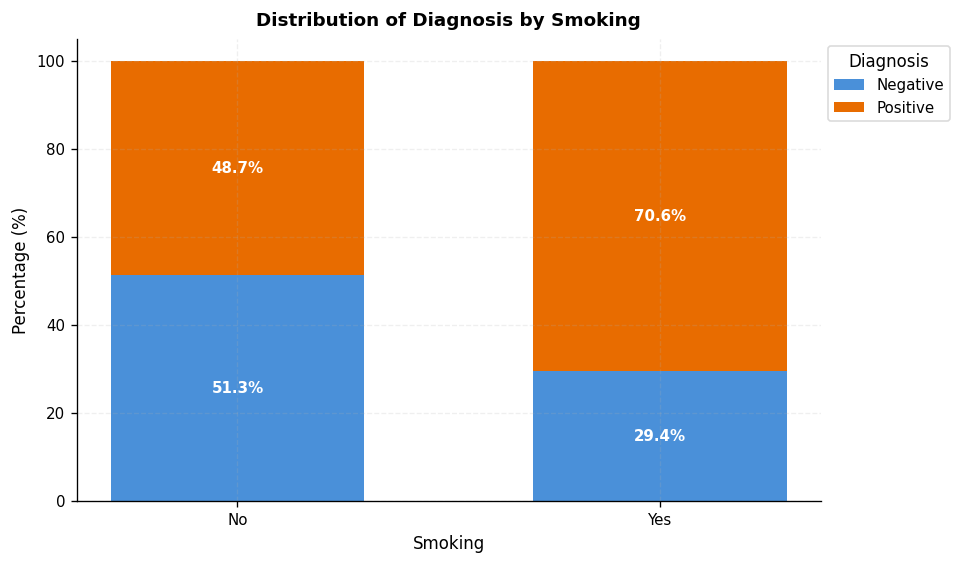

,bin,Negative,Positive,total,negative_pct,positive_pct
0,High,27,138,165,16.4,83.6
1,Low,459,519,978,46.9,53.1
2,Medium,278,279,557,49.9,50.1


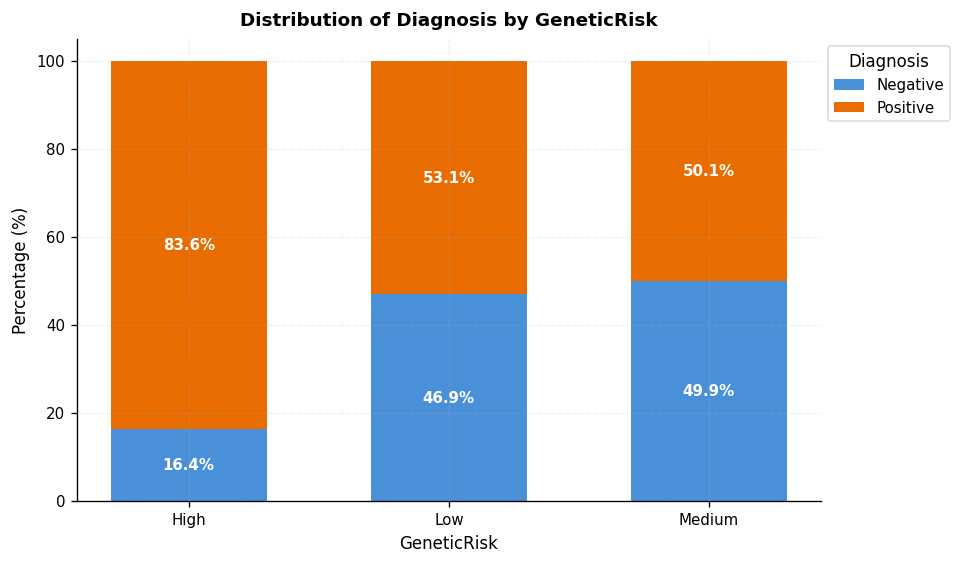

,bin,Negative,Positive,total,negative_pct,positive_pct
0,No,687,771,1458,47.1,52.9
1,Yes,77,165,242,31.8,68.2


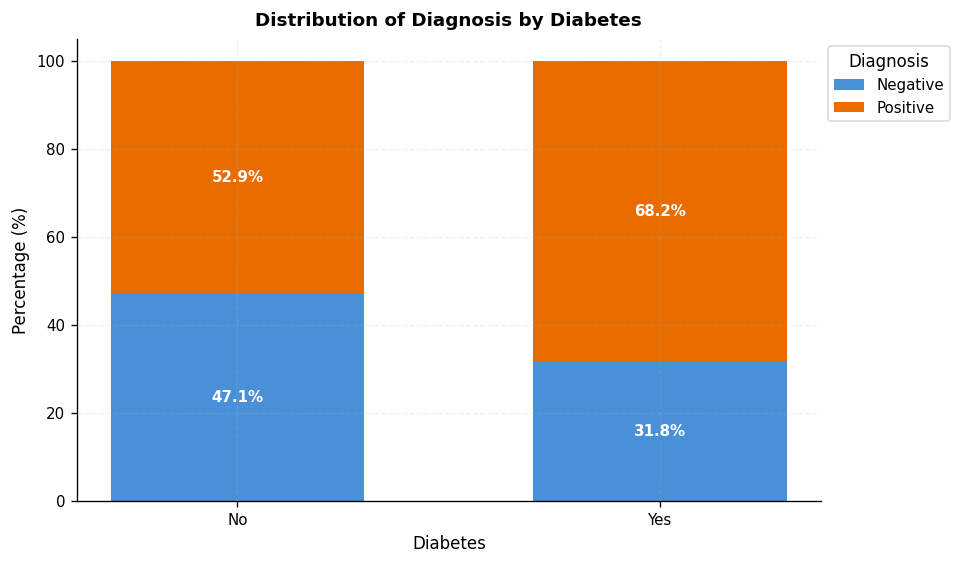

,bin,Negative,Positive,total,negative_pct,positive_pct
0,No,698,739,1437,48.6,51.4
1,Yes,66,197,263,25.1,74.9


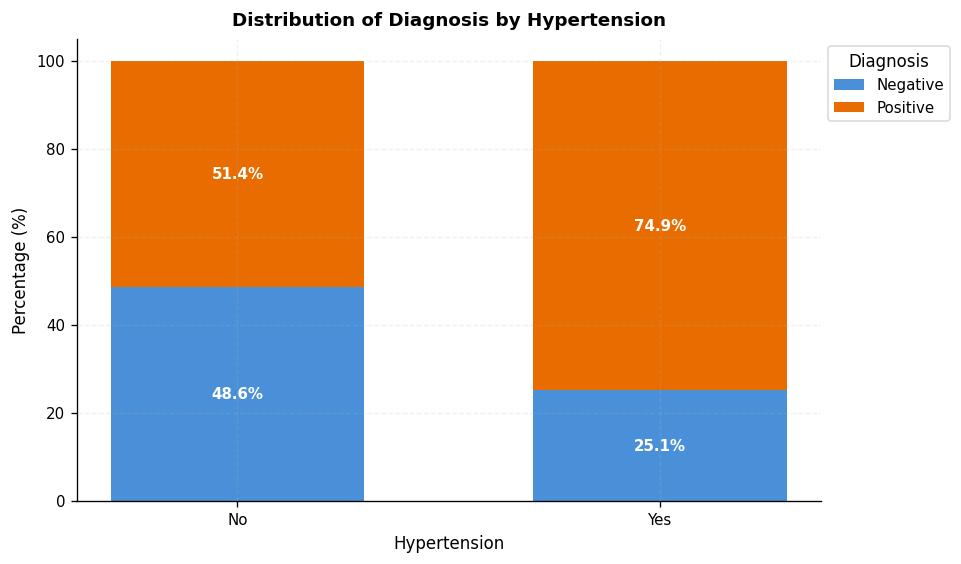

In [8]:
for feat in CATEGORICAL_FEATURES:
    ct = crosstabulate(df, feat, TARGET)
    display(ct[['bin', 'Negative', 'Positive', 'total', 'negative_pct', 'positive_pct']])
    plot_percentage_stacked_chart(
        ct,
        title=f'Distribution of Diagnosis by {feat}',
        xlabel=feat,
    )
    plt.show()
    print()

## 5. Statistical Tests

Welch's t-tests for numeric features, chi-square tests for categorical features.

In [9]:
results = []
pos = df[df[TARGET] == 'Positive']
neg = df[df[TARGET] == 'Negative']

for feat in NUMERIC_FEATURES:
    t, p = stats.ttest_ind(pos[feat].dropna(), neg[feat].dropna(), equal_var=False)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    results.append({'Feature': feat, 'Test': "Welch's t-test", 't/chi2': round(t, 3), 'p-value': round(p, 4), 'Sig': sig})

for feat in CATEGORICAL_FEATURES:
    ct = pd.crosstab(df[feat], df[TARGET])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    results.append({'Feature': feat, 'Test': 'Chi-square', 't/chi2': round(chi2, 3), 'p-value': round(p, 4), 'Sig': sig})

pd.DataFrame(results).set_index('Feature')

,Test,t/chi2,p-value,Sig
Feature,,,,
Age,Welch's t-test,6.497,0.0,***
BMI,Welch's t-test,6.968,0.0,***
AlcoholConsumption,Welch's t-test,15.422,0.0,***
PhysicalActivity,Welch's t-test,-4.880,0.0,***
LiverFunctionTest,Welch's t-test,15.487,0.0,***
Gender,Chi-square,60.325,0.0,***
Smoking,Chi-square,67.166,0.0,***
GeneticRisk,Chi-square,61.584,0.0,***
Diabetes,Chi-square,19.025,0.0,***


## 6. Correlation Matrix (Numeric Features)

Pearson correlations between numeric features. Low multicollinearity is ideal for linear models.

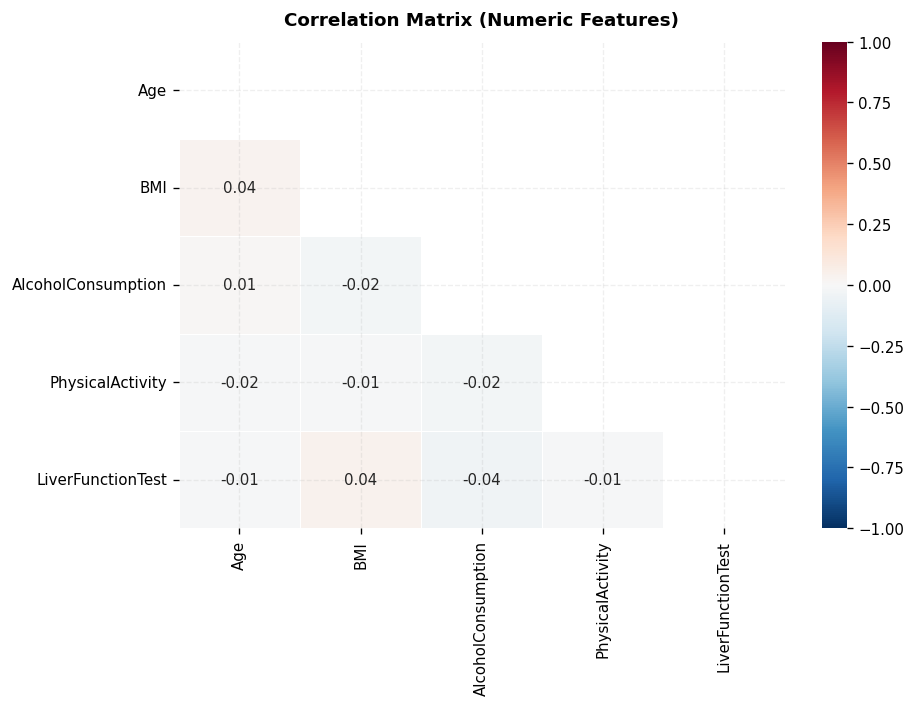

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_correlation_matrix(df, NUMERIC_FEATURES, ax=ax)
fig.tight_layout()
plt.show()

## 7. Weight of Evidence (WoE) Analysis

WoE measures the log-odds of a feature bin being associated with the positive class.  
Information Value (IV) quantifies the total predictive power of each feature.

| IV Range | Predictive Power |
|----------|------------------|
| < 0.02   | Useless          |
| 0.02–0.1 | Weak             |
| 0.1–0.3  | Medium           |
| 0.3–0.5  | Strong           |
| > 0.5    | Suspicious       |

In [11]:
all_features = NUMERIC_FEATURES + CATEGORICAL_FEATURES
iv_df = iv_summary_table(df, all_features, TARGET)
# Rename columns for cleaner display
iv_df = iv_df.rename(columns={'Total_IV': 'IV', 'Interpretation': 'Predictive Power'})
iv_df.sort_values('IV', ascending=False).reset_index(drop=True)

,Feature,IV,Predictive Power
0,LiverFunctionTest,0.681142,Suspicious
1,AlcoholConsumption,0.680826,Suspicious
2,GeneticRisk,0.176950,Medium
3,Age,0.175207,Medium
4,Smoking,0.169576,Medium
5,BMI,0.147100,Medium
6,Gender,0.147020,Medium
7,PhysicalActivity,0.131184,Medium
8,Hypertension,0.128608,Medium
9,Diabetes,0.048830,Weak


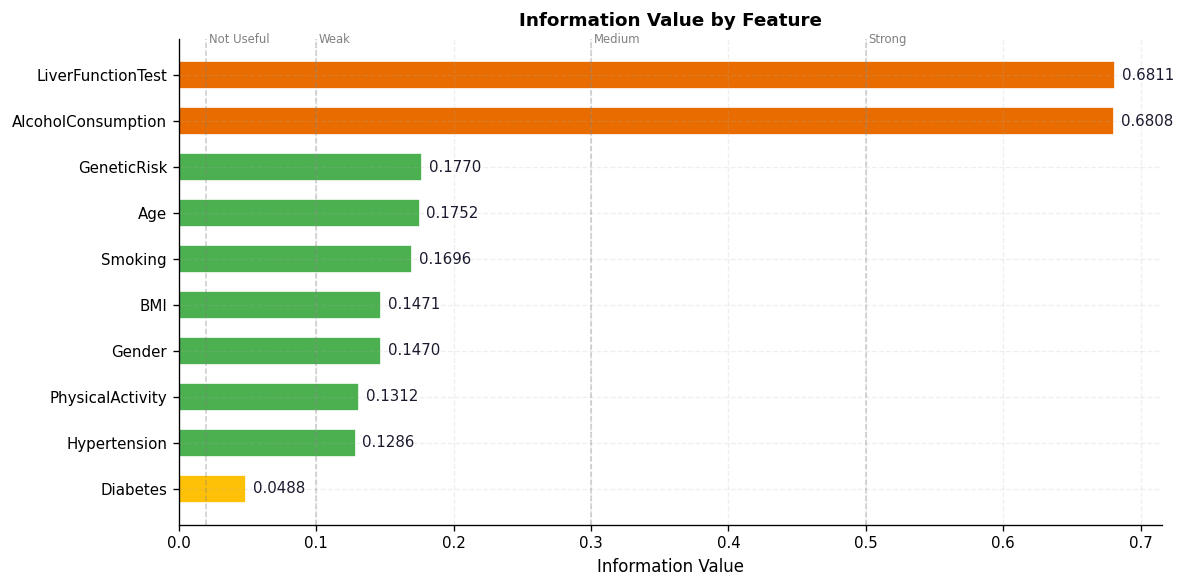

In [12]:
# IV comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
plot_iv_comparison(df, all_features, TARGET, ax=ax)
fig.tight_layout()
plt.show()

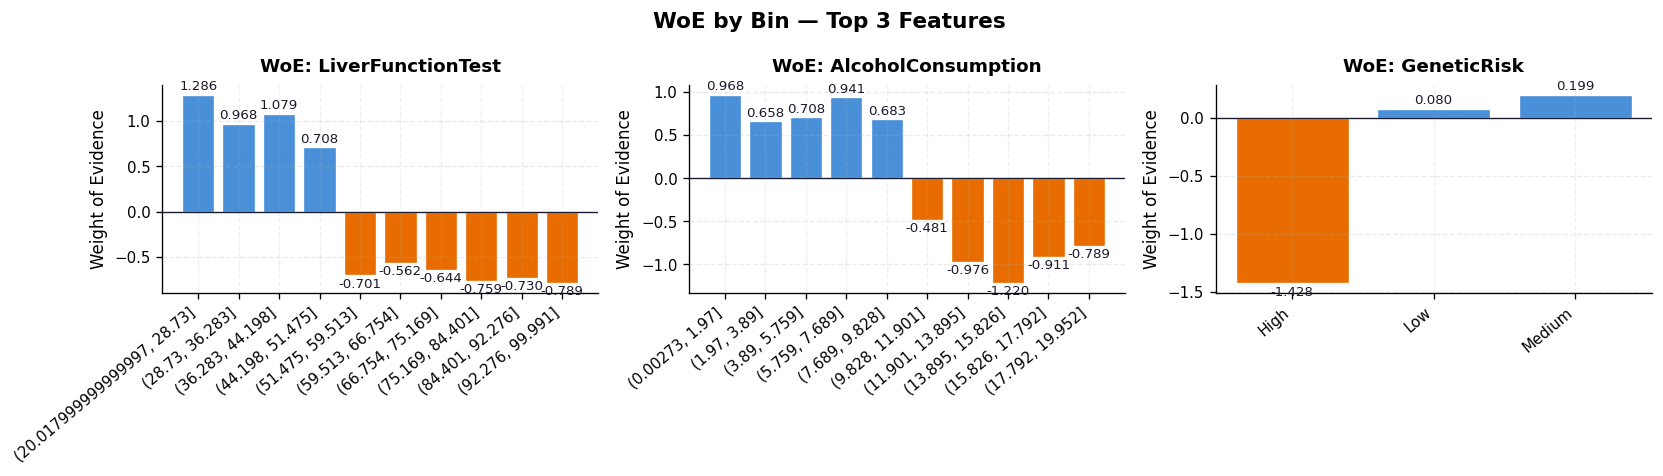

In [13]:
# WoE bar charts for top 3 features by IV
top3 = iv_df.sort_values('IV', ascending=False).head(3)['Feature'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, top3):
    plot_woe_bars(df, feat, TARGET, ax=ax)
fig.suptitle('WoE by Bin — Top 3 Features', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 8. WoE Monotonicity Validation

For ordinal features (GeneticRisk) we expect a monotonic WoE trend.  
Non-monotonic patterns may indicate binning issues or noise.

In [14]:
result = validate_woe_monotonicity(
    df, 'GeneticRisk', TARGET,
    categories=['Low', 'Medium', 'High']
)
print(f"GeneticRisk WoE monotonicity:")
print(f"  Is monotonic : {result['is_monotonic']}")
print(f"  Direction    : {result['direction']}")
print(f"  WoE values   : {result['woe_values']}")
if result['violations']:
    print(f"  Violations   : {result['violations']}")

GeneticRisk WoE monotonicity:
  Is monotonic : False
  Direction    : non-monotonic
  WoE values   : [('Low', 0.0801940142057279), ('Medium', 0.19945701918034314), ('High', -1.428369131841804)]
  Violations   : [('Medium', 'High', 0.19945701918034314, -1.428369131841804)]


## 9. Key Findings Summary

In [15]:
pos_rate = (df[TARGET] == 'Positive').mean()
top_feat = iv_df.sort_values('IV', ascending=False).iloc[0]

print('=== Key Findings ===')
print(f'Dataset: {len(df):,} records, {pos_rate:.1%} positive cases')
print(f'Top predictor: {top_feat["Feature"]} (IV = {top_feat["IV"]:.3f} — {top_feat["Predictive Power"]})')
print(f'All numeric features are statistically significant (t-test p < 0.001)')
print(f'No missing values or duplicates')
print(f'Low multicollinearity — suitable for linear models')

=== Key Findings ===
Dataset: 1,700 records, 55.1% positive cases
Top predictor: LiverFunctionTest (IV = 0.681 — Suspicious)
All numeric features are statistically significant (t-test p < 0.001)
No missing values or duplicates
Low multicollinearity — suitable for linear models
